In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

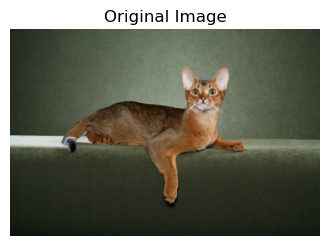

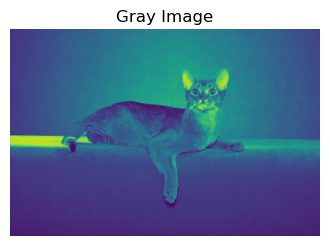

In [2]:
plt.rcParams['figure.figsize'] = (4,4)

image_path = "./dataset/images/Abyssinian_1.jpg"
annotation_path = "./dataset/images/Abyssinian_1.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(1)
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')

plt.figure(2)
plt.title("Gray Image")
plt.imshow(gray)
plt.axis("off")

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

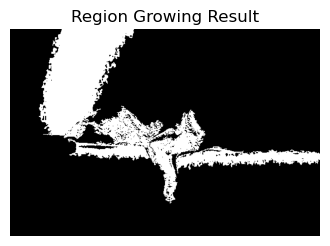

In [3]:
def region_growing_demo(image, seed, threshold=15):
    h, w = image.shape
    segmented = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=bool)
    seed_value = image[seed]
    stack = [seed]
    while stack:
        x, y = stack.pop()
        if visited[x, y]:
            continue
        visited[x, y] = True
        if abs(int(image[x, y]) - int(seed_value)) < threshold:
            segmented[x, y] = 255
        #   4-connected neighbors
            neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
            for nx, ny in neighbors:
                if 0 <= nx < h and 0 <= ny < w:
                    stack.append((nx, ny))
    return segmented
# Try different seeds and thresholds to observe behavior
h, w = gray.shape
seed = (h//2, w//2) # let's start with the central pixel
region_result = region_growing_demo(gray, seed, threshold=20)
plt.title("Region Growing Result")
plt.imshow(region_result, cmap='gray')
plt.axis('off')

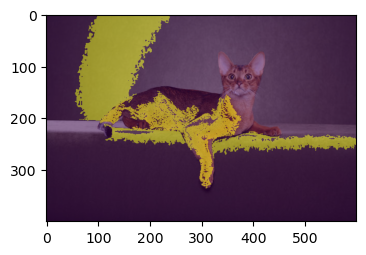

In [4]:
fig, ax = plt.subplots()
plt.imshow(image)
plt.imshow(region_result, alpha=0.5)
plt.show()


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

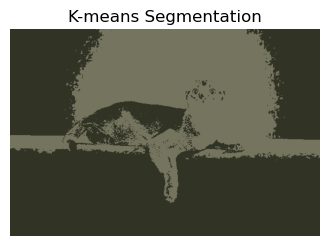

In [5]:
Z = image.reshape((-1, 3))
Z = np.float32(Z)

K = 2

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(image.shape)

plt.title("K-means Segmentation")
plt.imshow(segmented_image)
plt.axis('off')

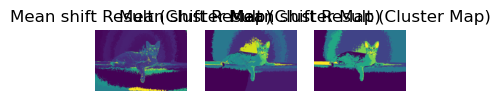

In [6]:
from sklearn.cluster import MeanShift


def MeanStuff(band = 10):
    h, w, _ = image.shape

    X = []
    for i in range(h):
        for j in range(w):
            r, g, b = image[i, j]
            X.append([r, g, b, i/10, j/10])

    X = np.array(X)

    ms = MeanShift(bandwidth=band, bin_seeding=True)
    labels = ms.fit_predict(X)

    segmented = labels.reshape((h, w))
    return segmented



im1 = MeanStuff(10)
im2 = MeanStuff(20)
im3 = MeanStuff(30)

plt.subplot(1, 3, 1)
plt.title("Mean shift Result (Cluster Map)")
plt.imshow(im1)
plt.axis('Off')

plt.subplot(1, 3, 2)
plt.title("Mean shift Result (Cluster Map)")
plt.imshow(im2)
plt.axis('Off')

plt.subplot(1, 3, 3)
plt.title("Mean shift Result (Cluster Map)")
plt.imshow(im3)
plt.axis('Off')
plt.show()

In [7]:
def region_growing(image, seed, threshold=15):
    h, w = image.shape
    segmented = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=bool)
    seed_value = image[seed]
    stack = [seed]
    while stack:
        x, y = stack.pop()
        if visited[x, y]:
            continue
        visited[x, y] = True
        if abs(int(image[x, y]) - int(seed_value)) < threshold:
            segmented[x, y] = 255
            # 4-connected neighbors
            neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
            for nx, ny in neighbors:
                if 0 <= nx < h and 0 <= ny < w:
                    stack.append((nx, ny))
    return segmented

def kmeans_segmentation(image, K=3):
    Z = image.reshape((-1, 3))
    Z = np.float32(Z)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(image.shape)
    return segmented_image

def mean_shift_segmentation(image, spatial_radius=10, color_radius=10):
    h, w, _ = image.shape
    X = []
    for i in range(h):
        for j in range(w):
            r, g, b = image[i, j]
            X.append([r, g, b, i/spatial_radius, j/spatial_radius])
    X = np.array(X)
    ms = MeanShift(bandwidth=color_radius, bin_seeding=True)
    labels = ms.fit_predict(X)
    segmented = labels.reshape((h, w))
    return segmented

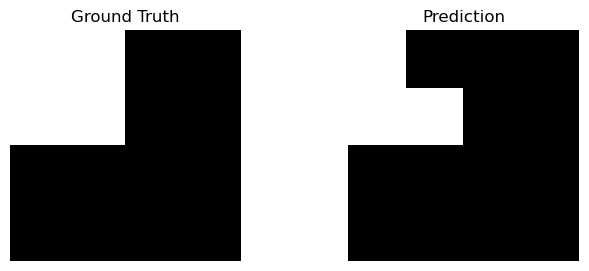

Example IoU: 0.750
Example Dice: 0.857


In [8]:
def compute_iou(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    iou = intersection / union if union > 0 else 0
    return iou

def compute_dice(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    dice = (2 * intersection) / (gt.sum() + pred.sum()) if (gt.sum() + pred.sum()) > 0 else 0
    return dice

gt_example = np.array([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])

pred_example = np.array([
    [1, 0, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])

plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
plt.title("Ground Truth")
plt.imshow(gt_example, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Prediction")
plt.imshow(pred_example, cmap='gray')
plt.axis('off')

plt.show()

iou_example = compute_iou(gt_example, pred_example)
dice_example = compute_dice(gt_example, pred_example)

print(f"Example IoU: {iou_example:.3f}")
print(f"Example Dice: {dice_example:.3f}")

In [9]:
import os
from tqdm import tqdm
# Create folder to save predictions
save_folder = "dataset/predictions"
os.makedirs(save_folder, exist_ok=True)
results = []
def process_and_save(image_folder, mask_folder, method='region'):
    results = []
    for filename in tqdm(os.listdir(image_folder)):
        # Image file is JPG
        img_path = os.path.join(image_folder, filename)
        # Corresponding mask file is PNG (replace extension)
        mask_name = os.path.splitext(filename)[0] + '.png'
        mask_path = os.path.join(mask_folder, mask_name)
        image = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        # Load GT mask
        gt = cv2.imread(mask_path, 0) # single-channel
        # Convert GT to binary mask (foreground = 1)
        gt_binary = np.where(gt == 1, 1, 0)
        # Valid mask (exclude pixels labeled 3)
        valid_mask = gt != 3
        # Apply segmentation method
        if method == 'region':
            h, w = gray.shape
            center_seed = (h//2, w//2)
            pred_mask = region_growing(gray, seed=center_seed, threshold=15)
        elif method == 'mean_shift':
            pred_seg = mean_shift_segmentation(image_rgb)
            # Use center pixel cluster for foreground
            h, w, _ = image_rgb.shape
            pred_mask = (pred_seg == pred_seg[h//2, w//2]).astype(np.uint8)
        elif method == 'kmeans':
            pred_seg = kmeans_segmentation(image_rgb, K=3)
            # Use center pixel cluster for foreground
            h, w, _ = image_rgb.shape
            center_cluster = pred_seg[h//2, w//2, 0] # R channel
            pred_mask = (pred_seg[:,:,0] == center_cluster).astype(np.uint8)
        else:
            raise ValueError("Unknown method")
        # Save segmentation result as PNG
        save_path = os.path.join(save_folder, f"{os.path.splitext(filename)[0]}_{method}.png")
        cv2.imwrite(save_path, (pred_mask*255).astype(np.uint8))
        # Compute metrics using valid pixels only
        iou = compute_iou(gt_binary[valid_mask], pred_mask[valid_mask])
        dice = compute_dice(gt_binary[valid_mask], pred_mask[valid_mask])
        results.append((filename, iou, dice, save_path))
    return results

# Example usage
image_folder = "dataset/images"
mask_folder = "dataset/masks"
#results = process_and_save(image_folder, mask_folder, method='mean_shift')
results += process_and_save(image_folder, mask_folder, method='region')
results += process_and_save(image_folder, mask_folder, method='kmeans')
# Print summary
for name, iou, dice, save_path in results:
    print(f"{name}: IoU={iou:.3f}, Dice={dice:.3f}, Saved: {save_path}")

100%|██████████| 5/5 [00:01<00:00,  4.26it/s]

Abyssinian_1.jpg: IoU=0.322, Dice=0.007, Saved: dataset/predictions/Abyssinian_1_region.png
Abyssinian_2.jpg: IoU=0.000, Dice=0.000, Saved: dataset/predictions/Abyssinian_2_region.png
Abyssinian_3.jpg: IoU=0.218, Dice=0.008, Saved: dataset/predictions/Abyssinian_3_region.png
Abyssinian_4.jpg: IoU=0.008, Dice=0.005, Saved: dataset/predictions/Abyssinian_4_region.png
Abyssinian_5.jpg: IoU=0.009, Dice=0.005, Saved: dataset/predictions/Abyssinian_5_region.png
Abyssinian_1.jpg: IoU=0.142, Dice=0.248, Saved: dataset/predictions/Abyssinian_1_kmeans.png
Abyssinian_2.jpg: IoU=0.012, Dice=0.025, Saved: dataset/predictions/Abyssinian_2_kmeans.png
Abyssinian_3.jpg: IoU=0.045, Dice=0.087, Saved: dataset/predictions/Abyssinian_3_kmeans.png
Abyssinian_4.jpg: IoU=0.330, Dice=0.497, Saved: dataset/predictions/Abyssinian_4_kmeans.png
Abyssinian_5.jpg: IoU=0.527, Dice=0.690, Saved: dataset/predictions/Abyssinian_5_kmeans.png


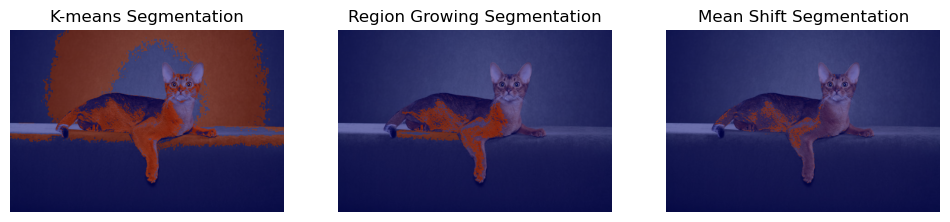

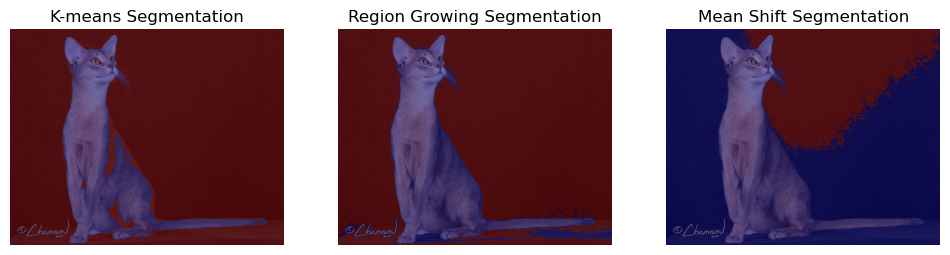

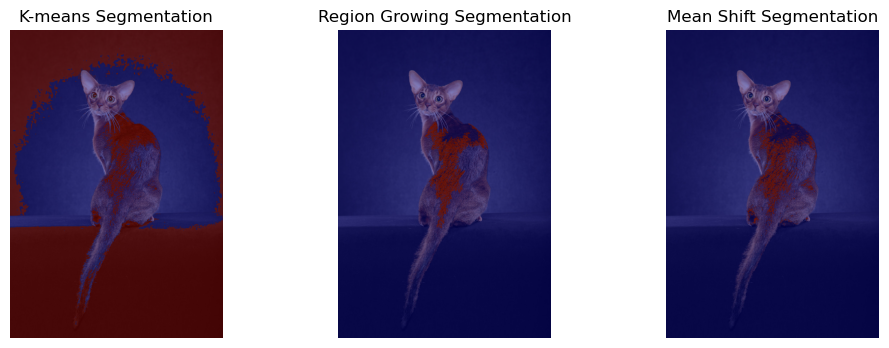

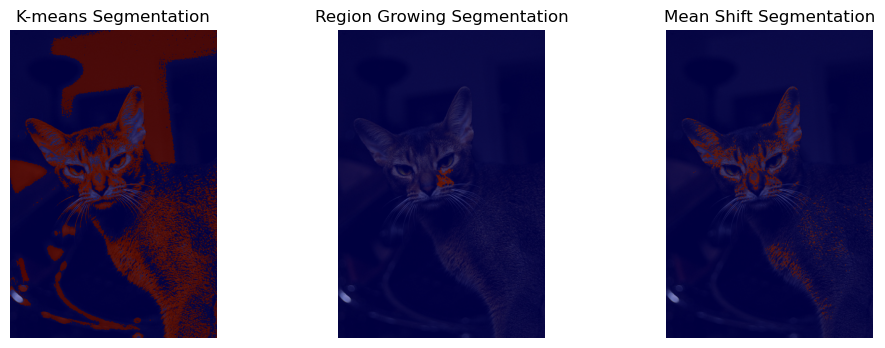

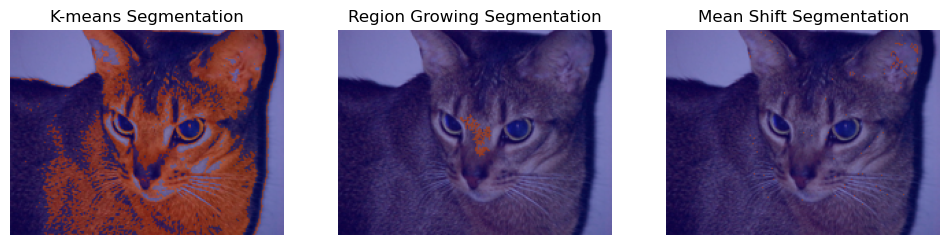

In [ ]:
for filename in os.listdir(image_folder):
    # Load original image
    img_path = os.path.join(image_folder, filename)
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load prediction mean shift result
    pred_path = os.path.join(save_folder, f"{os.path.splitext(filename)[0]}_mean_shift.png")
    mean_shift_segmentation = cv2.imread(pred_path, 0) / 255 # binary mask

    # Load region mask
    region_path = os.path.join(save_folder, f"{os.path.splitext(filename)[0]}_region.png")
    region_mask = cv2.imread(region_path, 0) / 255

    # Load k-means mask
    kmeans_path = os.path.join(save_folder, f"{os.path.splitext(filename)[0]}_kmeans.png")
    kmeans_mask = cv2.imread(kmeans_path, 0) / 255



    # overlay mask over og image
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("K-means Segmentation")
    plt.imshow(image_rgb)
    plt.imshow(kmeans_mask, alpha=0.5, cmap='jet')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.title("Region Growing Segmentation")
    plt.imshow(image_rgb)
    plt.imshow(region_mask, alpha=0.5, cmap='jet')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.title("Mean Shift Segmentation")
    plt.imshow(image_rgb)
    plt.imshow(mean_shift_segmentation, alpha=0.5, cmap='jet')
    plt.axis('off')
    plt.show()
    

    
